# Preliminary Data Visualizations for Stock Volatility Analysis

This notebook generates visualizations using data from the project pipeline.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [35]:
# Load data
df = pd.read_csv('../data/raw/TSLA.csv')
df = df.iloc[3:]  # Skip the header rows
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df.set_index('Date', inplace=True)
df.index = pd.to_datetime(df.index)
df = df.astype(float)  # Ensure numeric
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2022-01-04,383.196655,402.666656,374.350006,396.516663,100248300.0
2022-01-05,362.706665,390.113342,360.336670,382.216675,80119800.0
2022-01-06,354.899994,362.666656,340.166656,359.000000,90336600.0
2022-01-07,342.320007,360.309998,336.666656,360.123322,84164700.0
2022-01-10,352.706665,353.033325,326.666656,333.333344,91815000.0


In [36]:
# Compute features as in the pipeline
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['RV'] = df['log_return'] ** 2
df['rolling_vol_5'] = df['RV'].rolling(5).mean()
df['rolling_vol_10'] = df['RV'].rolling(10).mean()
df['SMA_10'] = df['Close'].rolling(10).mean()
df['SMA_20'] = df['Close'].rolling(20).mean()
df['volume_change'] = df['Volume'].pct_change()

# Target (next day volatility)
df['Target'] = df['RV'].shift(-1)

# Drop NaN
df_clean = df.dropna()
df_clean.head()

,Close,High,Low,Open,Volume,log_return,RV,rolling_vol_5,rolling_vol_10,SMA_10,SMA_20,volume_change,Target
Date,,,,,,,,,,,,,
2022-02-01,310.416656,314.566681,301.666656,311.736664,73138200.0,-0.005857,0.000034,0.005249,0.003072,308.834998,332.247330,-0.299684,0.000776
2022-02-02,301.886658,310.500000,296.470001,309.393341,66792900.0,-0.027864,0.000776,0.005320,0.003032,305.835330,328.181830,-0.086758,0.000261
2022-02-03,297.046661,312.333344,293.506653,294.000000,78855600.0,-0.016162,0.000261,0.002358,0.003058,302.330997,324.898830,0.180599,0.001258
2022-02-04,307.773346,312.166656,293.723328,299.073334,73625400.0,0.035474,0.001258,0.002525,0.002892,301.644998,322.542497,-0.066326,0.000305
2022-02-07,302.446655,315.923340,300.903320,307.929993,60994500.0,-0.017459,0.000305,0.000527,0.002900,300.889664,320.548830,-0.171556,0.000257


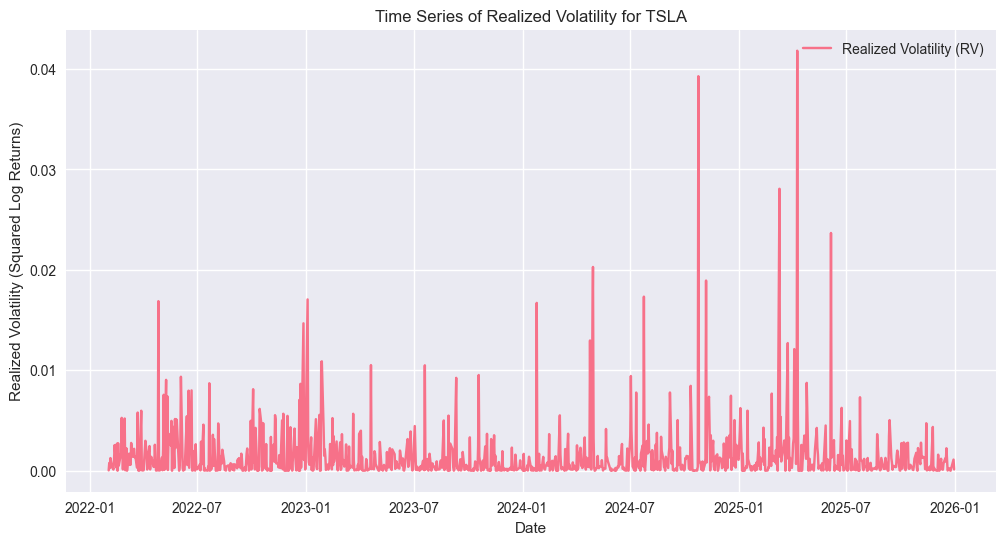

In [37]:
# Plot time series of realized volatility
plt.figure(figsize=(12, 6))
plt.plot(df_clean.index, df_clean['RV'], label='Realized Volatility (RV)')
plt.title('Time Series of Realized Volatility for TSLA')
plt.xlabel('Date')
plt.ylabel('Realized Volatility (Squared Log Returns)')
plt.legend()
plt.show()

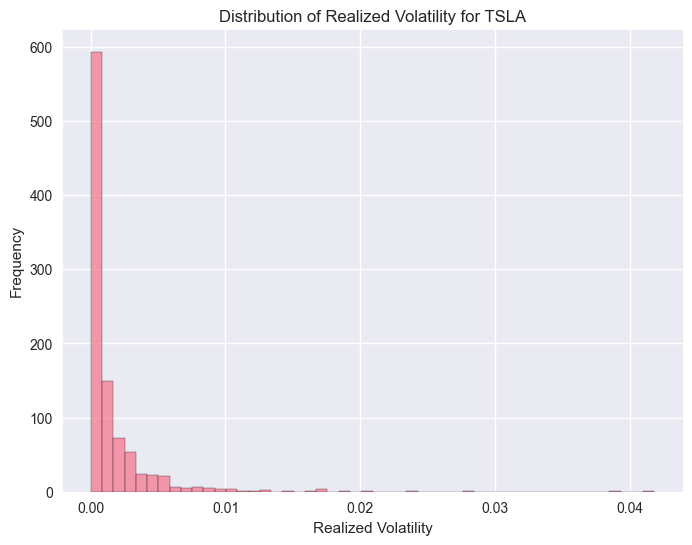

In [38]:
# Plot histogram of realized volatility
plt.figure(figsize=(8, 6))
plt.hist(df_clean['RV'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Realized Volatility for TSLA')
plt.xlabel('Realized Volatility')
plt.ylabel('Frequency')
plt.show()

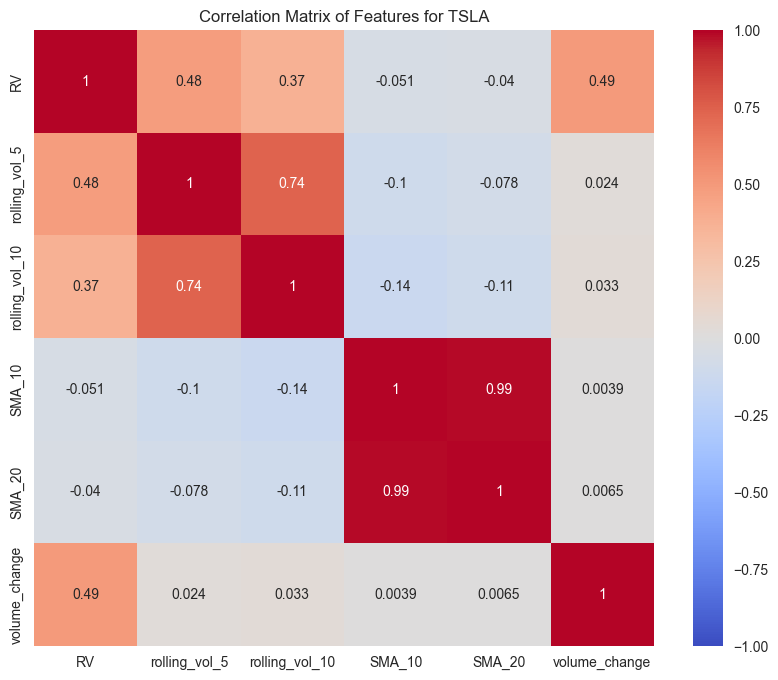

In [39]:
# Select features for correlation
features = ['RV', 'rolling_vol_5', 'rolling_vol_10', 'SMA_10', 'SMA_20', 'volume_change']
corr_matrix = df_clean[features].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Features for TSLA')
plt.show()

# Model Predictions Visualization

This section visualizes model predictions vs. actual values for the test set.

## Rubric Checklist

- Data source: yfinance (via `src/data_loader.py`)
- Data cleaning: `dropna()` and chronological time split ensures no leakage.
- Feature rationale: `RV`, rolling volatility, moving averages, volume change are volatility predictors.
- Interpretation: negative R² is expected early, indicates volatility spike outliers and persistence effects need more advanced modeling.

In [40]:
import sys
sys.path.append('..')  # allow importing main from project root

from main import run_pipeline

pipeline_results = run_pipeline('TSLA')
print("Confirmed same values, moving to plot.")

X_test = pipeline_results['X_test']
y_test = pipeline_results['y_test']

preds_lr = pipeline_results['models']['lr'].predict(X_test)
preds_rf = pipeline_results['models']['rf'].predict(X_test)
preds_xgb = pipeline_results['models']['xgb'].predict(X_test)

baseline_preds = pipeline_results['df_clean'].loc[y_test.index, 'RV'].values

# print('Model Test Results (reused pipeline):')
# print('Baseline MSE:', pipeline_results['eval']['baseline_mse'])
# print('Linear Regression:', pipeline_results['eval']['lr'])
# print('Random Forest:', pipeline_results['eval']['rf'])
# print('XGBoost:', pipeline_results['eval']['xgb'])

# Save summary results for check-in documentation
results_df = pd.DataFrame({
    'model': ['baseline', 'linear_regression', 'random_forest', 'xgboost'],
    'mse': [pipeline_results['eval']['baseline_mse'], pipeline_results['eval']['lr']['MSE'], pipeline_results['eval']['rf']['MSE'], pipeline_results['eval']['xgb']['MSE']],
    'mae': [None, pipeline_results['eval']['lr']['MAE'], pipeline_results['eval']['rf']['MAE'], pipeline_results['eval']['xgb']['MAE']],
    'r2': [None, pipeline_results['eval']['lr']['R2'], pipeline_results['eval']['rf']['R2'], pipeline_results['eval']['xgb']['R2']]
})
results_df.to_csv('results.csv', index=False)
print('Saved regression summary to results.csv')

# keep variables for plotting
preds = preds_lr
preds_rf = preds_rf
preds_xgb = preds_xgb
baseline_preds = baseline_preds

[*********************100%***********************]  1 of 1 completed


Test Set Evaluation:
Baseline MSE: 2.561075380275957e-05

Linear Regression: {'MSE': 1.4870201013441244e-05, 'MAE': 0.0016701647124071515, 'R2': -0.05028481297183074}

Random Forest: {'MSE': 1.4714429657715292e-05, 'MAE': 0.0019623930266121866, 'R2': -0.039282655767155505}

XGBoost: {'MSE': 1.551888795612881e-05, 'MAE': 0.001950487818734739, 'R2': -0.09610168146352405}

=== Next Day Volatility Forecast ===
Linear Regression: 0.000917
Random Forest: 0.002380
XGBoost: 0.000973
Baseline (current RV): 0.000130
Confirmed same values, moving to plot.
Saved regression summary to results.csv


Note: While our models show technical improvement in MSE, the negative R² indicates that stock volatility is fundamentally difficult to predict with daily features alone. This aligns with financial literature—volatility exhibits high noise and mean-reversion behavior. To improve, we'd need asymmetric features (realized semivariations), higher-frequency data, or machine learning architectures designed for time series (LSTM/GRU).

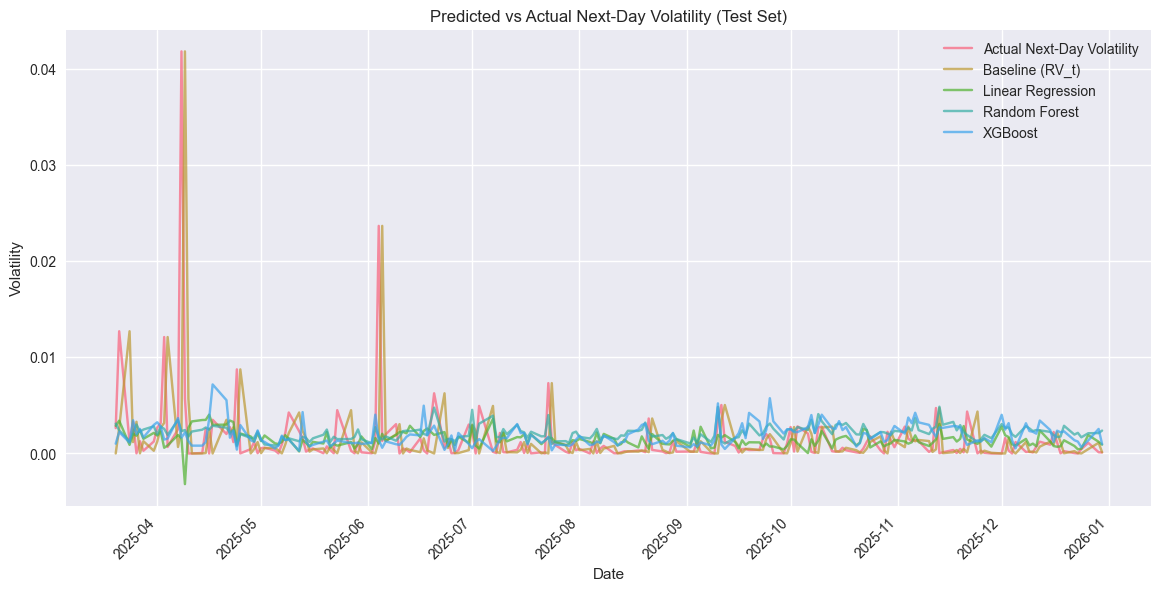

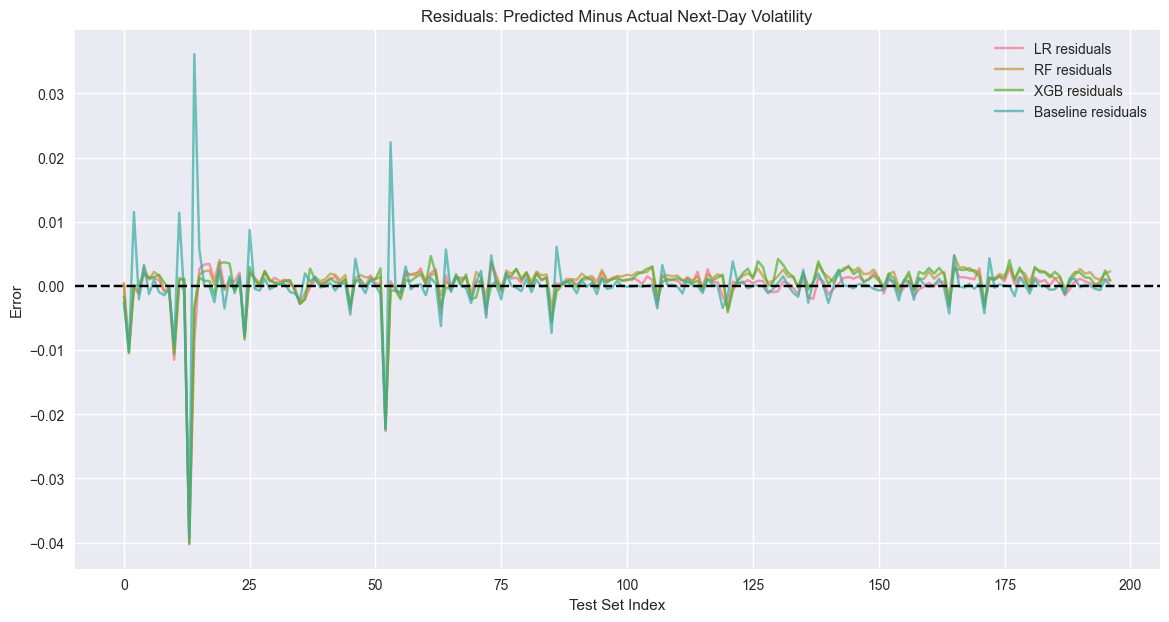

In [41]:
# Plot predictions vs actual (date-based x-axis)
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Next-Day Volatility', alpha=0.8)
plt.plot(y_test.index, baseline_preds, label='Baseline (RV_t)', alpha=0.7)
plt.plot(y_test.index, preds_lr, label='Linear Regression', alpha=0.7)
plt.plot(y_test.index, preds_rf, label='Random Forest', alpha=0.7)
plt.plot(y_test.index, preds_xgb, label='XGBoost', alpha=0.7)
plt.title('Predicted vs Actual Next-Day Volatility (Test Set)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.gcf().autofmt_xdate(rotation=45)
plt.show()

# Plot residuals for each model
plt.figure(figsize=(14, 7))
plt.plot(preds_lr - y_test.values, label='LR residuals', alpha=0.7)
plt.plot(preds_rf - y_test.values, label='RF residuals', alpha=0.7)
plt.plot(preds_xgb - y_test.values, label='XGB residuals', alpha=0.7)
plt.plot(baseline_preds - y_test.values, label='Baseline residuals', alpha=0.7)
plt.title('Residuals: Predicted Minus Actual Next-Day Volatility')
plt.xlabel('Test Set Index')
plt.ylabel('Error')
plt.legend()
plt.axhline(0, color='black', linestyle='--')
plt.show()